# Statistical Indicators

Core statistical concepts used to understand, describe, and validate data.

---

## Table of Contents
1. [Mean, Variance, Standard Deviation](#1-mean-variance-standard-deviation)
2. [Covariance & Correlation](#2-covariance--correlation)
3. [Z-score & Standardisation](#3-z-score--standardisation)
4. [Central Limit Theorem](#4-central-limit-theorem)
5. [Confidence Intervals](#5-confidence-intervals)
6. [Hypothesis Testing — t-test & p-value](#6-hypothesis-testing--t-test--p-value)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import norm, t as t_dist
import os

os.makedirs('img', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'text.color':       '#eee',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.8,
    'font.family':      'monospace',
    'axes.titlesize':   12,
    'axes.labelsize':   11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'
YELLOW = '#ffd60a'

---
## 1. Mean, Variance, Standard Deviation

The three numbers that summarise any distribution.

**Mean** $\mu$ — the centre of mass:
$$\mu = \bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$$

**Variance** $\sigma^2$ — average squared deviation from the mean:
$$\sigma^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \mu)^2$$

For a **sample** (estimating from data, not the full population), use $n-1$ in the denominator — this is **Bessel's correction**, which removes a systematic underestimation bias:
$$s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2$$

**Standard deviation** $\sigma$ — same unit as $x$, directly interpretable:
$$\sigma = \sqrt{\sigma^2}$$

**Intuition**: variance penalises large deviations quadratically. Two datasets can share the same mean but have very different variances — a model trained on one may fail on the other.

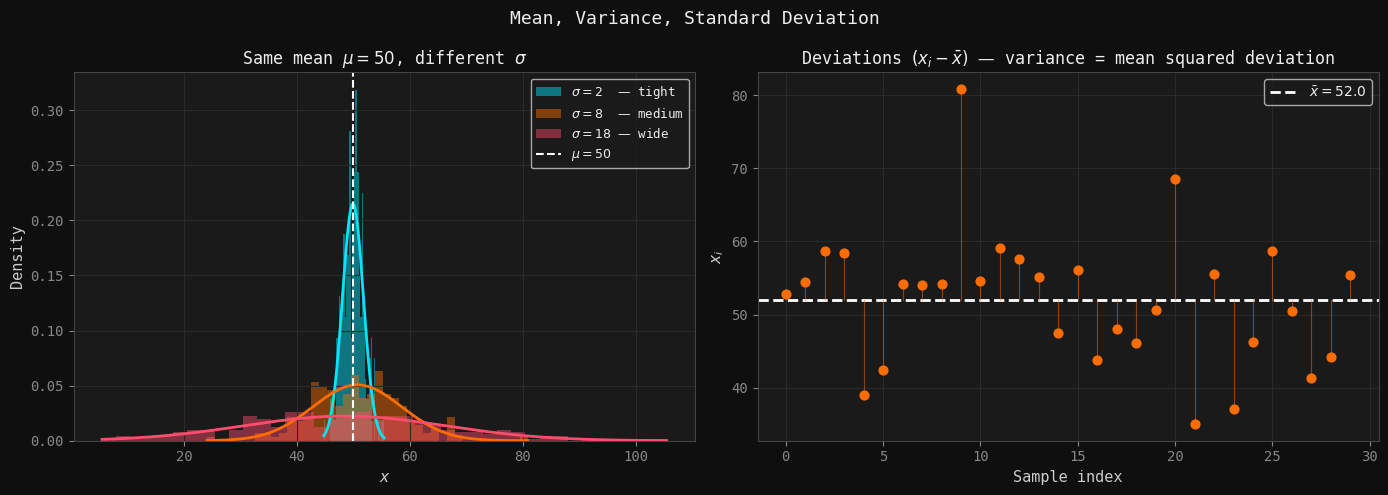

In [2]:
np.random.seed(42)

# Three datasets: same mean, different variance
mu = 50
datasets = [
    (np.random.normal(mu, 2,  200), ACCENT,  '$\\sigma=2$  — tight'),
    (np.random.normal(mu, 8,  200), ORANGE,  '$\\sigma=8$  — medium'),
    (np.random.normal(mu, 18, 200), RED,     '$\\sigma=18$ — wide'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mean, Variance, Standard Deviation', fontsize=13)

# Histograms
ax = axes[0]
for data, color, label in datasets:
    ax.hist(data, bins=40, alpha=0.45, color=color, label=label, density=True)
    x_range = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_range, norm.pdf(x_range, np.mean(data), np.std(data)),
            color=color, lw=2)
ax.axvline(mu, color='white', lw=1.5, linestyle='--', label=f'$\\mu = {mu}$')
ax.set_xlabel('$x$'); ax.set_ylabel('Density')
ax.set_title('Same mean $\\mu=50$, different $\\sigma$')
ax.legend(fontsize=9); ax.grid(True)

# Variance decomposition on a single dataset
ax = axes[1]
d = datasets[1][0][:30]  # small subset for clarity
mean_d = np.mean(d)
ax.scatter(range(len(d)), d, color=ORANGE, s=40, zorder=5)
ax.axhline(mean_d, color='white', lw=2, linestyle='--', label=f'$\\bar{{x}}={mean_d:.1f}$')
for i, xi in enumerate(d):
    ax.plot([i, i], [mean_d, xi], color=ORANGE, lw=0.8, alpha=0.5)
ax.set_xlabel('Sample index'); ax.set_ylabel('$x_i$')
ax.set_title('Deviations $(x_i - \\bar{x})$ — variance = mean squared deviation')
ax.legend(fontsize=10); ax.grid(True)

plt.tight_layout()
plt.savefig('img/s01_mean_variance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Covariance & Correlation

**Covariance** measures whether two variables move together:
$$\text{Cov}(X, Y) = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

Its magnitude depends on the units of $X$ and $Y$ — hard to interpret directly.

**Pearson correlation** $\rho$ normalises it to $[-1, 1]$:
$$\rho_{XY} = \frac{\text{Cov}(X,Y)}{\sigma_X \, \sigma_Y}$$

| $\rho$ | Meaning |
|--------|--------|
| $+1$ | Perfect positive linear relationship |
| $0$ | No linear relationship |
| $-1$ | Perfect negative linear relationship |

**Critical warning**: $\rho = 0$ does not mean independence — only that there is no *linear* relationship. Two variables can be strongly dependent yet have $\rho = 0$.

The **correlation matrix** for $p$ features has $\rho_{ij}$ at position $(i,j)$ and 1s on the diagonal. It is the standard tool for detecting multicollinearity before fitting a model.

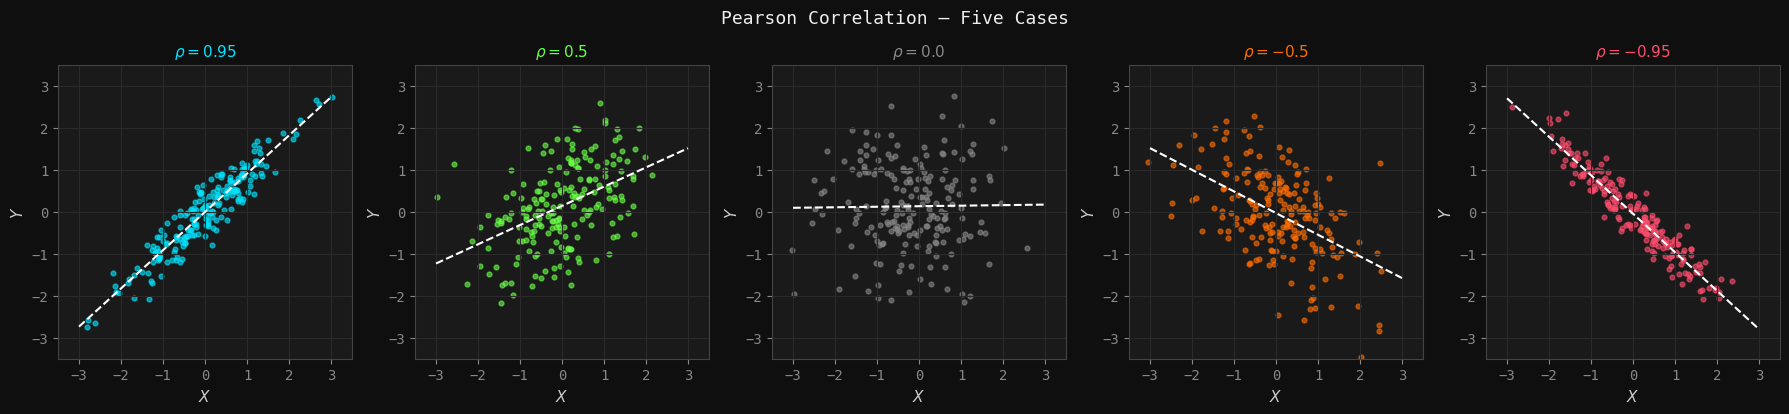

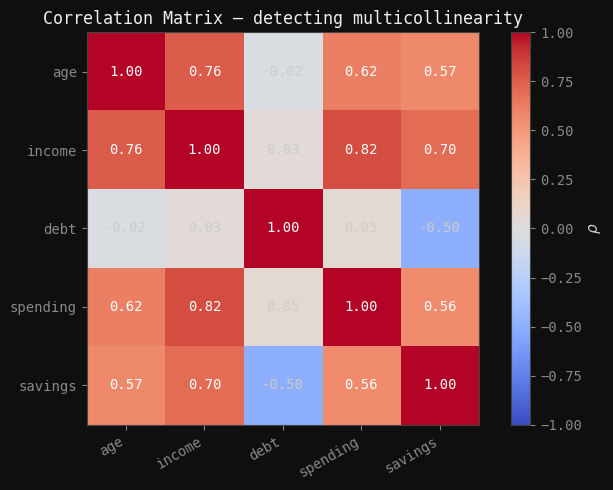

In [3]:
np.random.seed(3)
n = 200

# Five correlation cases
cases = [
    ( 0.95, ACCENT,  '$\\rho=0.95$'),
    ( 0.5,  GREEN,   '$\\rho=0.5$'),
    ( 0.0,  '#888',  '$\\rho=0.0$'),
    (-0.5,  ORANGE,  '$\\rho=-0.5$'),
    (-0.95, RED,     '$\\rho=-0.95$'),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Pearson Correlation — Five Cases', fontsize=13)

for ax, (rho, color, label) in zip(axes, cases):
    cov = np.array([[1, rho], [rho, 1]])
    xy  = np.random.multivariate_normal([0, 0], cov, n)
    ax.scatter(xy[:,0], xy[:,1], color=color, s=12, alpha=0.6)
    # Regression line
    m, b, *_ = stats.linregress(xy[:,0], xy[:,1])
    xr = np.linspace(-3, 3, 100)
    ax.plot(xr, m*xr+b, color='white', lw=1.5, linestyle='--')
    ax.set_title(label, color=color, fontsize=11)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal'); ax.grid(True)
    ax.set_xlabel('$X$'); ax.set_ylabel('$Y$')

plt.tight_layout()
plt.savefig('img/s02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation matrix heatmap
np.random.seed(1)
p = 5
feature_names = ['age', 'income', 'debt', 'spending', 'savings']
raw = np.random.randn(300, p)
# Inject correlations manually
raw[:,1] = 0.8*raw[:,0] + 0.6*np.random.randn(300)  # income ~ age
raw[:,4] = 0.7*raw[:,1] - 0.5*raw[:,2] + 0.5*np.random.randn(300)  # savings
raw[:,3] = 0.6*raw[:,1] + 0.4*np.random.randn(300)   # spending ~ income
corr_mat = np.corrcoef(raw.T)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='$\\rho$')
ax.set_xticks(range(p)); ax.set_yticks(range(p))
ax.set_xticklabels(feature_names, rotation=30, ha='right')
ax.set_yticklabels(feature_names)
for i in range(p):
    for j in range(p):
        ax.text(j, i, f'{corr_mat[i,j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if abs(corr_mat[i,j]) > 0.5 else '#ccc')
ax.set_title('Correlation Matrix — detecting multicollinearity')
plt.tight_layout()
plt.savefig('img/s03_corr_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Z-score & Standardisation

The **z-score** of an observation $x_i$ measures how many standard deviations it is from the mean:

$$z_i = \frac{x_i - \mu}{\sigma}$$

**Standardisation** (a.k.a. z-score normalisation) applies this to every value in a feature:
$$X_{\text{std}} = \frac{X - \mu}{\sigma} \implies \mathbb{E}[X_{\text{std}}] = 0,\quad \text{Var}(X_{\text{std}}) = 1$$

**Why it matters in ML**:
- Gradient descent converges much faster when features are on the same scale — elongated loss surfaces become more circular
- Regularisation (L1/L2) penalises all features equally only if they are standardised
- Distance-based models (KNN, KMeans, SVM) are completely dominated by the highest-magnitude feature without standardisation
- A z-score $|z| > 3$ is a common outlier flag — only ~0.3% of Gaussian data falls there

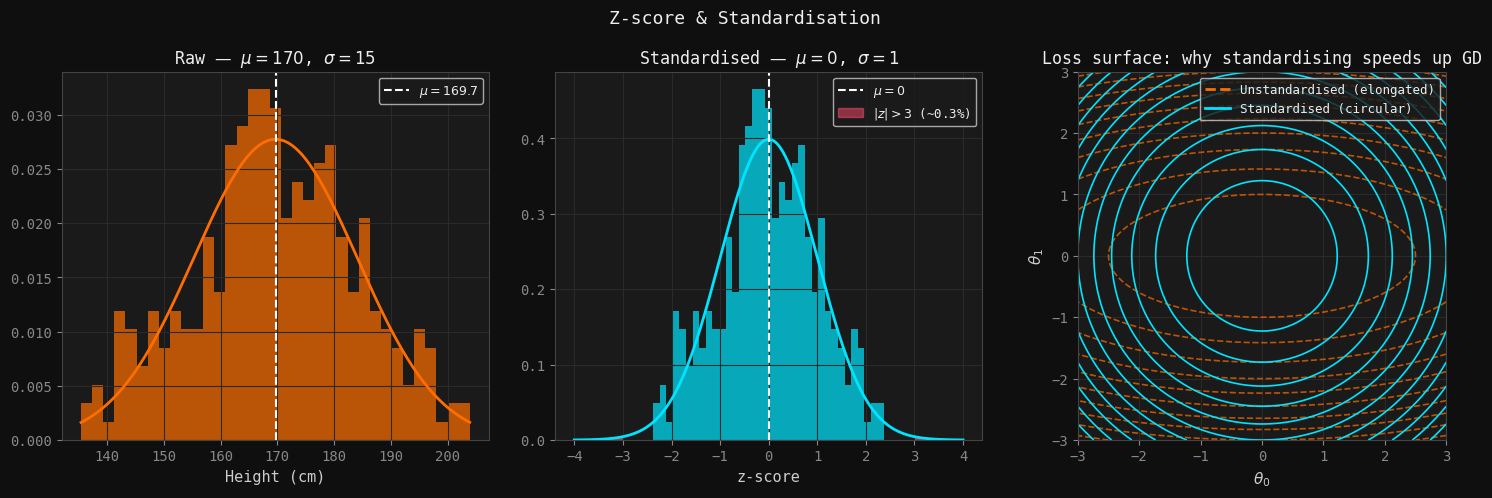

In [4]:
np.random.seed(7)
raw_feature = np.random.normal(170, 15, 300)  # e.g. height in cm
z_scores = (raw_feature - raw_feature.mean()) / raw_feature.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Z-score & Standardisation', fontsize=13)

# Raw distribution
ax = axes[0]
ax.hist(raw_feature, bins=35, color=ORANGE, alpha=0.7, density=True)
xr = np.linspace(raw_feature.min(), raw_feature.max(), 300)
ax.plot(xr, norm.pdf(xr, raw_feature.mean(), raw_feature.std()), color=ORANGE, lw=2)
ax.axvline(raw_feature.mean(), color='white', lw=1.5, linestyle='--',
           label=f'$\\mu={raw_feature.mean():.1f}$')
ax.set_xlabel('Height (cm)'); ax.set_title('Raw — $\\mu=170$, $\\sigma=15$')
ax.legend(fontsize=9); ax.grid(True)

# Standardised
ax = axes[1]
ax.hist(z_scores, bins=35, color=ACCENT, alpha=0.7, density=True)
zr = np.linspace(-4, 4, 300)
ax.plot(zr, norm.pdf(zr), color=ACCENT, lw=2)
ax.axvline(0, color='white', lw=1.5, linestyle='--', label='$\\mu=0$')
# Shade outlier zone
ax.fill_between(zr, norm.pdf(zr), where=(np.abs(zr) > 3),
                color=RED, alpha=0.5, label='$|z|>3$ (~0.3%)')
ax.set_xlabel('z-score'); ax.set_title('Standardised — $\\mu=0$, $\\sigma=1$')
ax.legend(fontsize=9); ax.grid(True)

# Effect on loss surface shape
ax = axes[2]
theta = np.linspace(-3, 3, 200)
T0, T1 = np.meshgrid(theta, theta)
# Without standardisation: feature scales differ by 10x
loss_unstd = (T0/0.5)**2 + (T1*5)**2
# With standardisation: circular
loss_std   = T0**2 + T1**2
ax.contour(T0, T1, loss_unstd, levels=12, colors=[ORANGE], linewidths=1.2, linestyles='--',
           alpha=0.7)
ax.contour(T0, T1, loss_std,   levels=12, colors=[ACCENT],  linewidths=1.2)
ax.plot([], [], color=ORANGE, linestyle='--', lw=2, label='Unstandardised (elongated)')
ax.plot([], [], color=ACCENT, lw=2, label='Standardised (circular)')
ax.set_title('Loss surface: why standardising speeds up GD')
ax.set_xlabel('$\\theta_0$'); ax.set_ylabel('$\\theta_1$')
ax.legend(fontsize=9); ax.grid(True); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('img/s04_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Central Limit Theorem

**Statement**: take any population with mean $\mu$ and finite variance $\sigma^2$. Draw $n$ samples and compute their mean $\bar{X}_n$. As $n \to \infty$:

$$\bar{X}_n \xrightarrow{d} \mathcal{N}\!\left(\mu,\, \frac{\sigma^2}{n}\right)$$

The distribution of the **sample mean** converges to a Gaussian, regardless of the shape of the original population.

**Standard error** — the standard deviation of the sample mean:
$$\text{SE} = \frac{\sigma}{\sqrt{n}}$$

Two things to notice:
- The spread of $\bar{X}_n$ shrinks as $\frac{1}{\sqrt{n}}$ — doubling precision requires 4× the data
- This is why Gaussian assumptions are so common — averages of almost anything are approximately Gaussian

In ML: mini-batch gradient estimates, model evaluation on test sets, A/B testing — all rely on the CLT.

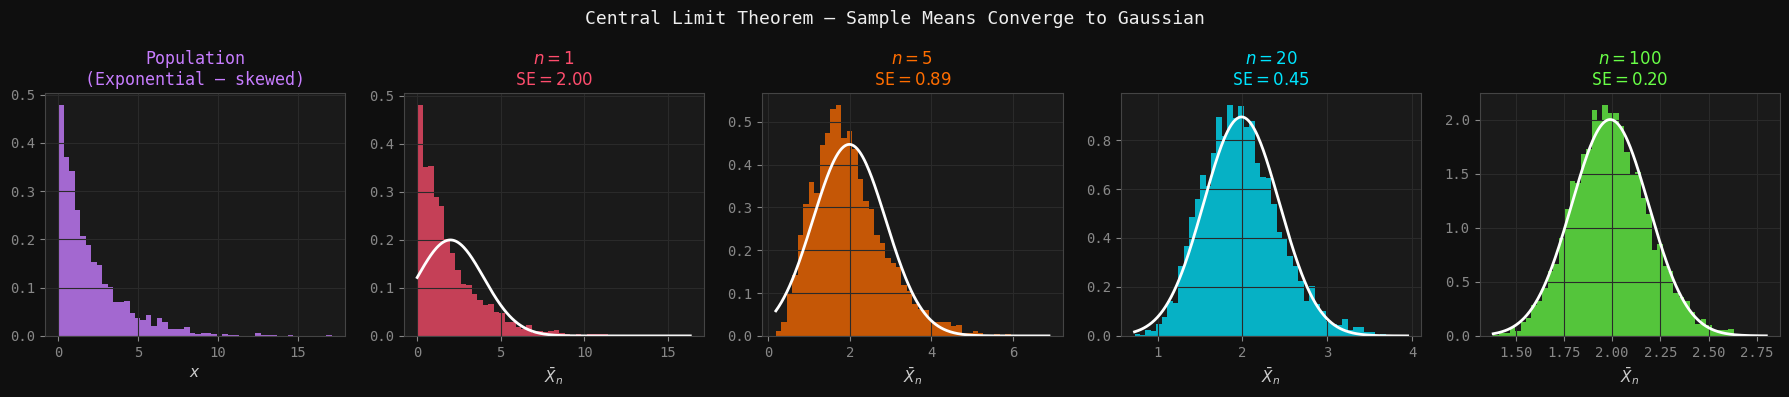

In [5]:
np.random.seed(0)
N_SIMS = 4000

# Original population: heavily right-skewed (exponential)
population = np.random.exponential(scale=2, size=50000)

sample_sizes = [1, 5, 20, 100]
colors_clt = [RED, ORANGE, ACCENT, GREEN]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Central Limit Theorem — Sample Means Converge to Gaussian', fontsize=13)

# Original population
ax = axes[0]
ax.hist(population[:2000], bins=50, color=PURPLE, alpha=0.8, density=True)
ax.set_title('Population\n(Exponential — skewed)', color=PURPLE)
ax.set_xlabel('$x$'); ax.grid(True)

for ax, n, color in zip(axes[1:], sample_sizes, colors_clt):
    sample_means = [np.mean(np.random.choice(population, n)) for _ in range(N_SIMS)]
    sample_means = np.array(sample_means)
    ax.hist(sample_means, bins=50, color=color, alpha=0.75, density=True)
    # Overlay theoretical Gaussian
    mu_th = np.mean(population)
    se_th = np.std(population) / np.sqrt(n)
    xr = np.linspace(sample_means.min(), sample_means.max(), 300)
    ax.plot(xr, norm.pdf(xr, mu_th, se_th), color='white', lw=2)
    ax.set_title(f'$n={n}$\nSE$={se_th:.2f}$', color=color)
    ax.set_xlabel('$\\bar{X}_n$'); ax.grid(True)

plt.tight_layout()
plt.savefig('img/s05_clt.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Confidence Intervals

A **95% confidence interval** (CI) for the population mean is:

$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

For a 95% CI: $z_{0.025} = 1.96$. If $\sigma$ is unknown (almost always in practice), replace it with the sample std $s$ and use the **t-distribution** with $n-1$ degrees of freedom.

**What it actually means** — the most misunderstood concept in statistics:

> If you repeat the experiment many times and compute a CI each time, **95% of those intervals will contain the true mean**. It does NOT mean there is a 95% probability the true mean is in *this particular* interval.

The true mean is fixed — it is either in the interval or it is not. The 95% refers to the **procedure**, not the specific interval.

**Width of a CI** depends on:
- $n$ ↑ → narrower (more data = more certainty)
- $\sigma$ ↑ → wider (more noise = less certainty)
- Confidence level ↑ (e.g. 99%) → wider

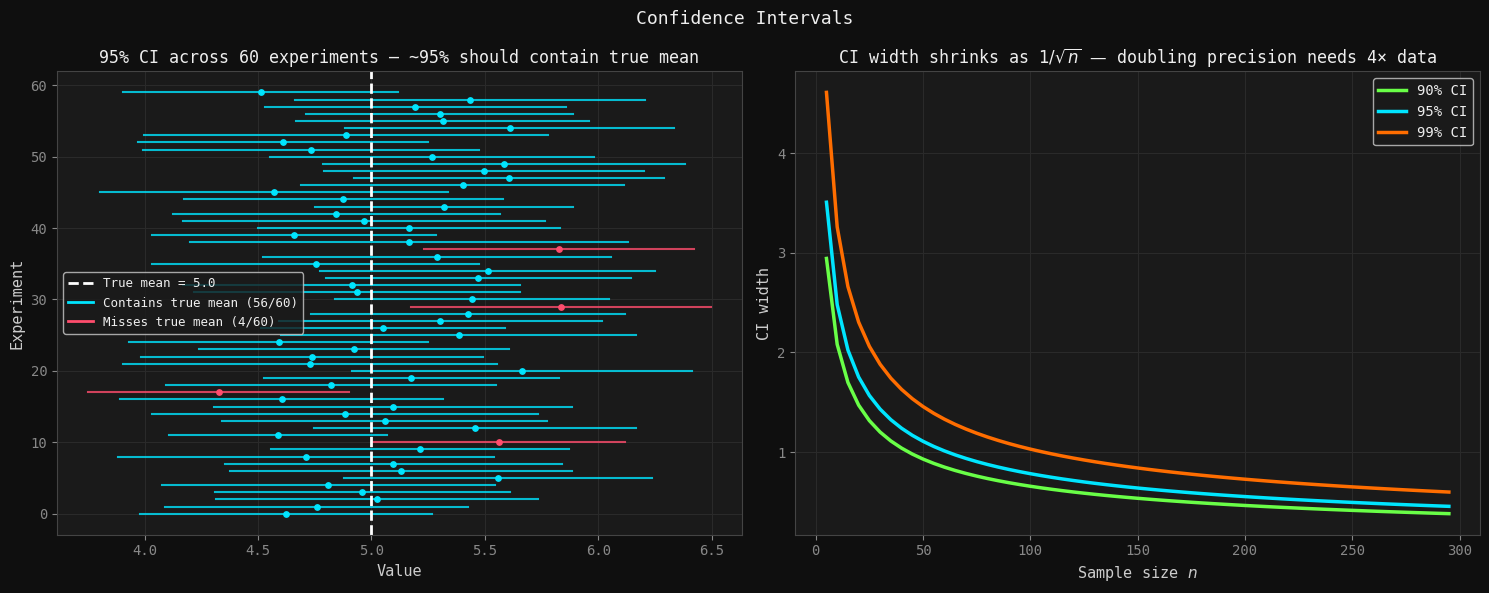

In [6]:
np.random.seed(42)
TRUE_MEAN = 5.0
TRUE_STD  = 2.0
N_SAMPLES = 30
N_EXPERIMENTS = 60
CONF = 0.95
z_crit = norm.ppf(0.5 + CONF/2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confidence Intervals', fontsize=13)

# --- Many CIs: some miss the true mean ---
ax = axes[0]
n_miss = 0
for i in range(N_EXPERIMENTS):
    sample = np.random.normal(TRUE_MEAN, TRUE_STD, N_SAMPLES)
    x_bar  = np.mean(sample)
    se     = np.std(sample, ddof=1) / np.sqrt(N_SAMPLES)
    ci_lo  = x_bar - z_crit * se
    ci_hi  = x_bar + z_crit * se
    contains = ci_lo <= TRUE_MEAN <= ci_hi
    if not contains: n_miss += 1
    color = ACCENT if contains else RED
    ax.plot([ci_lo, ci_hi], [i, i], color=color, lw=1.5, alpha=0.8)
    ax.scatter(x_bar, i, color=color, s=15, zorder=5)

ax.axvline(TRUE_MEAN, color='white', lw=2, linestyle='--', label=f'True mean = {TRUE_MEAN}')
ax.plot([], [], color=ACCENT, lw=2, label=f'Contains true mean ({N_EXPERIMENTS-n_miss}/{N_EXPERIMENTS})')
ax.plot([], [], color=RED,   lw=2, label=f'Misses true mean ({n_miss}/{N_EXPERIMENTS})')
ax.set_xlabel('Value'); ax.set_ylabel('Experiment')
ax.set_title(f'{int(CONF*100)}% CI across {N_EXPERIMENTS} experiments — ~{int(CONF*100)}% should contain true mean')
ax.legend(fontsize=9); ax.grid(True)

# --- CI width vs sample size ---
ax = axes[1]
sample_sizes_ci = np.arange(5, 300, 5)
for conf, color, label in [(0.90, GREEN, '90% CI'), (0.95, ACCENT, '95% CI'), (0.99, ORANGE, '99% CI')]:
    z = norm.ppf(0.5 + conf/2)
    widths = 2 * z * TRUE_STD / np.sqrt(sample_sizes_ci)
    ax.plot(sample_sizes_ci, widths, color=color, lw=2.5, label=label)
ax.set_xlabel('Sample size $n$'); ax.set_ylabel('CI width')
ax.set_title('CI width shrinks as $1/\\sqrt{n}$ — doubling precision needs 4× data')
ax.legend(fontsize=10); ax.grid(True)

plt.tight_layout()
plt.savefig('img/s06_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Hypothesis Testing — t-test & p-value

**Hypothesis testing** is a formal procedure for deciding whether observed data is consistent with a baseline assumption.

- **Null hypothesis $H_0$**: the default claim — e.g. "the two group means are equal"
- **Alternative hypothesis $H_1$**: what you want to detect — e.g. "the means differ"

### The t-statistic

For a one-sample test (is the mean equal to $\mu_0$?):

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

For a two-sample test (are two group means equal?):

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

Under $H_0$, this statistic follows a **Student's t-distribution** with $\nu$ degrees of freedom.

### The p-value

$$p = P(|T| \geq |t_{\text{obs}}| \mid H_0 \text{ true})$$

The probability of observing a result **at least as extreme** as the one you got, assuming $H_0$ is true.

- Small $p$ (typically $< 0.05$): the data is unlikely under $H_0$ → reject $H_0$
- Large $p$: no evidence against $H_0$ — note: this does **not** mean $H_0$ is true

**What the p-value is NOT**: it is not the probability that $H_0$ is true. It is not the probability of a false positive. The threshold $\alpha = 0.05$ is a convention, not a law.

### The t-distribution vs Gaussian

The t-distribution has heavier tails than $\mathcal{N}(0,1)$ — it accounts for the extra uncertainty from estimating $\sigma$ from data. As $n \to \infty$, it converges to the standard normal.

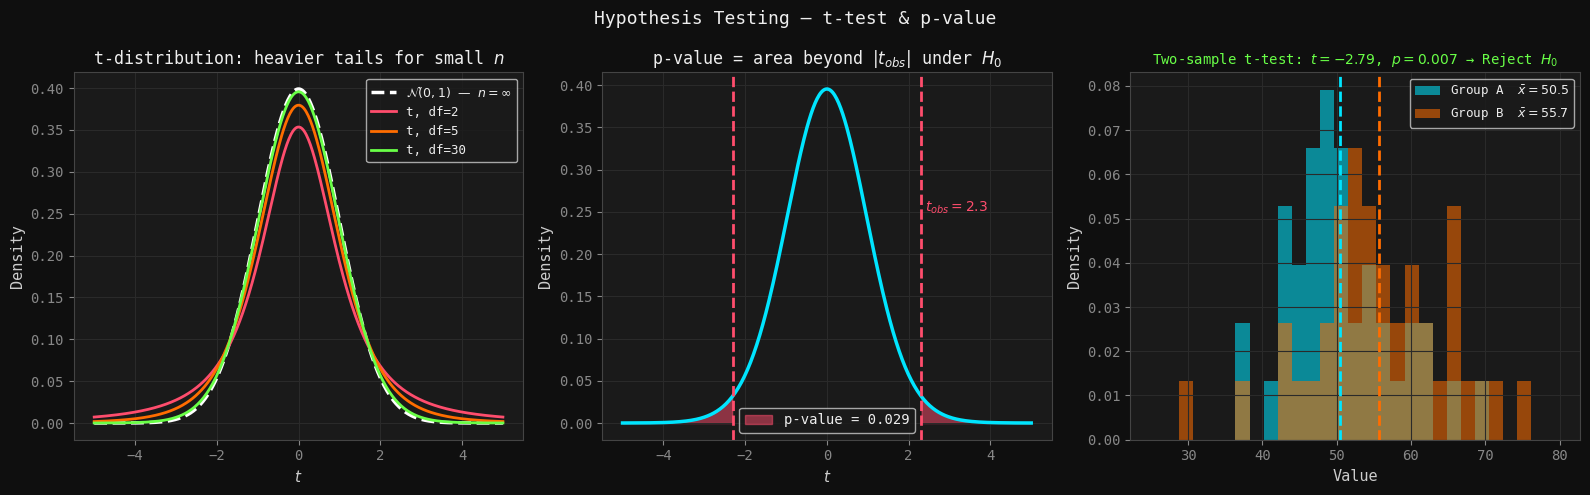

In [7]:
np.random.seed(5)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hypothesis Testing — t-test & p-value', fontsize=13)

# --- t-distribution vs Gaussian ---
ax = axes[0]
x_t = np.linspace(-5, 5, 400)
ax.plot(x_t, norm.pdf(x_t), color='white', lw=2.5, linestyle='--', label='$\\mathcal{N}(0,1)$ — $n=\\infty$')
for df, color in [(2, RED), (5, ORANGE), (30, GREEN)]:
    ax.plot(x_t, t_dist.pdf(x_t, df), color=color, lw=2, label=f't, df={df}')
ax.set_title('t-distribution: heavier tails for small $n$')
ax.set_xlabel('$t$'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True)

# --- p-value visualised on the t-distribution ---
ax = axes[1]
df_ex = 28  # n=30, df=29
t_obs = 2.3
x_t2 = np.linspace(-5, 5, 400)
pdf_t = t_dist.pdf(x_t2, df_ex)
ax.plot(x_t2, pdf_t, color=ACCENT, lw=2.5)
# Shade p-value regions (two-tailed)
ax.fill_between(x_t2, pdf_t, where=(x_t2 >= t_obs),  color=RED, alpha=0.5)
ax.fill_between(x_t2, pdf_t, where=(x_t2 <= -t_obs), color=RED, alpha=0.5)
p_val = 2 * t_dist.sf(abs(t_obs), df_ex)
ax.axvline( t_obs, color=RED, lw=2, linestyle='--')
ax.axvline(-t_obs, color=RED, lw=2, linestyle='--')
ax.text(t_obs+0.1, 0.25, f'$t_{{obs}}={t_obs}$', color=RED, fontsize=10)
ax.fill_between([], [], color=RED, alpha=0.5, label=f'p-value = {p_val:.3f}')
ax.set_title('p-value = area beyond $|t_{obs}|$ under $H_0$')
ax.set_xlabel('$t$'); ax.set_ylabel('Density')
ax.legend(fontsize=10); ax.grid(True)

# --- Two-sample t-test: two groups ---
ax = axes[2]
group_A = np.random.normal(50, 8, 40)
group_B = np.random.normal(55, 9, 40)
t_stat, p_value = stats.ttest_ind(group_A, group_B)

bins = np.linspace(25, 80, 30)
ax.hist(group_A, bins=bins, alpha=0.55, color=ACCENT,  density=True, label=f'Group A  $\\bar{{x}}={group_A.mean():.1f}$')
ax.hist(group_B, bins=bins, alpha=0.55, color=ORANGE, density=True, label=f'Group B  $\\bar{{x}}={group_B.mean():.1f}$')
ax.axvline(group_A.mean(), color=ACCENT,  lw=2, linestyle='--')
ax.axvline(group_B.mean(), color=ORANGE, lw=2, linestyle='--')
verdict = 'Reject $H_0$' if p_value < 0.05 else 'Fail to reject $H_0$'
color_v = GREEN if p_value < 0.05 else RED
ax.set_title(f'Two-sample t-test: $t={t_stat:.2f}$, $p={p_value:.3f}$ → {verdict}',
             color=color_v, fontsize=10)
ax.set_xlabel('Value'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/s07_ttest_pvalue.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary Table

| Indicator | Formula | What it tells you |
|-----------|---------|-------------------|
| Mean | $\bar{x} = \frac{1}{n}\sum x_i$ | Centre of the distribution |
| Variance | $s^2 = \frac{1}{n-1}\sum(x_i-\bar{x})^2$ | Average squared spread |
| Std dev | $s = \sqrt{s^2}$ | Spread in same unit as $x$ |
| Covariance | $\frac{1}{n-1}\sum(x_i-\bar{x})(y_i-\bar{y})$ | Do $X$ and $Y$ move together? |
| Correlation | $\rho = \text{Cov}(X,Y)/(\sigma_X\sigma_Y)$ | Normalised, scale-free co-movement |
| Z-score | $z = (x-\mu)/\sigma$ | How many $\sigma$ from the mean |
| Standard error | $\text{SE} = \sigma/\sqrt{n}$ | Uncertainty on the sample mean |
| 95% CI | $\bar{x} \pm 1.96 \cdot \text{SE}$ | Range that covers $\mu$ in 95% of experiments |
| t-statistic | $(\bar{x}-\mu_0)/(s/\sqrt{n})$ | Signal-to-noise ratio for the mean |
| p-value | $P(\|T\| \geq \|t_{obs}\| \mid H_0)$ | Evidence against $H_0$ — not a probability of truth |

---